# Rate of Penetration (ROP) Prediction using Machine Learning

## Objective
The goal of this notebook is to build a regression model that can predict **Rate of Penetration (ROP)** during active drilling operations.

ROP describes how quickly the drill bit penetrates the formation. Instead of using every rig observation, we first isolate meaningful active-drilling records, clean the target, select relevant drilling parameters, and then compare several ensemble regression algorithms.

### Workflow
1. Load the master cleaned drilling dataset.
2. Keep active drilling observations with positive ROP.
3. Remove only the most extreme ROP outliers.
4. Select drilling, hydraulic, depth, directional, and mud-related features.
5. Split the data into training and testing sets.
6. Handle missing feature values using median imputation.
7. Train Random Forest, XGBoost, LightGBM, and CatBoost.
8. Compare the models using MAE, RMSE, and R².
9. Tune the best-performing model.
10. Interpret the final model using feature importance and diagnostic plots.

> **Important:** This is a supervised **regression** problem because the target, `rop_depth_hour`, is a continuous numerical value.


In [49]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Regression Models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## 1. Load the cleaned drilling dataset

We begin with `drilling_data_cleaned.csv`, which is the **master cleaned dataset** created during the general data-cleaning stage.

General cleaning is kept separate from ROP-specific preprocessing so that the same master dataset can also be reused for other ML tasks.


In [50]:
#loading dataset
df = pd.read_csv(r"drilling_data_cleaned.csv") 

## 2. Initial dataset inspection

Before modeling, we inspect a few rows and check the dataset dimensions, data types, and available columns. This helps confirm that the expected drilling variables are present and that the dataset loaded correctly.


In [51]:
# inspecting the dataset
df.head()

,block_position,weight_on_bit,hookload,slips_set,rop_depth_hour,on_bottom,top_drive_rpm,top_drive_torque_ft_lbs,flow_in,pump_pressure,...,depth_hole_tvd,differential_pressure,downhole_torque,drill_mode,year,month,day,hour,day_of_week,timestamp
0,43.55661,46.948985,123.68008,0.0,0.0,0.0,0.31182,0.0,57.19964,40.23666,...,7389.89,-531.16685,1894.27245,0.0,2020,10,25,12,6,2020-10-25 12:00:00
1,43.55661,46.948985,123.68008,0.0,0.0,0.0,0.31182,0.0,57.19964,40.23666,...,7389.89,-531.16685,1894.27245,0.0,2020,10,25,12,6,2020-10-25 12:00:00
2,43.55661,46.948985,123.68008,0.0,0.0,0.0,0.31182,0.0,57.19964,40.23666,...,7389.89,-531.16685,1894.27245,0.0,2020,10,25,12,6,2020-10-25 12:00:00
3,43.55661,46.948985,123.68008,0.0,0.0,0.0,0.31182,0.0,0.00000,40.23666,...,7389.89,-531.16685,1894.27245,0.0,2020,10,25,12,6,2020-10-25 12:00:00
4,43.55661,46.948985,123.68008,0.0,0.0,0.0,0.31182,0.0,0.00000,40.23666,...,7389.89,-531.16685,1894.27245,0.0,2020,10,25,12,6,2020-10-25 12:00:00


In [52]:
df.shape

(598709, 37)

In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 598709 entries, 0 to 598708
Data columns (total 37 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   block_position           598664 non-null  float64
 1   weight_on_bit            598709 non-null  float64
 2   hookload                 598709 non-null  float64
 3   slips_set                598644 non-null  float64
 4   rop_depth_hour           598709 non-null  float64
 5   on_bottom                598665 non-null  float64
 6   top_drive_rpm            598709 non-null  float64
 7   top_drive_torque_ft_lbs  598664 non-null  float64
 8   flow_in                  598709 non-null  float64
 9   pump_pressure            598709 non-null  float64
 10  spm_total                598709 non-null  float64
 11  pit_volume_active        598709 non-null  float64
 12  pit_gl_active            598709 non-null  float64
 13  gas_total_units          552440 non-null  float64
 14  trip_volume_act

In [54]:
df.columns.tolist()

['block_position',
 'weight_on_bit',
 'hookload',
 'slips_set',
 'rop_depth_hour',
 'on_bottom',
 'top_drive_rpm',
 'top_drive_torque_ft_lbs',
 'flow_in',
 'pump_pressure',
 'spm_total',
 'pit_volume_active',
 'pit_gl_active',
 'gas_total_units',
 'trip_volume_active',
 'trip_gl',
 'return_flow',
 'rig_mode',
 'rockit_on_off',
 'mwd_inclination',
 'mwd_azimuth',
 'mud_temp',
 'h2s_01',
 'rig_event_code',
 'total_depth',
 'bit_diameter',
 'bit_rpm',
 'depth_hole_tvd',
 'differential_pressure',
 'downhole_torque',
 'drill_mode',
 'year',
 'month',
 'day',
 'hour',
 'day_of_week',
 'timestamp']

## 3. ROP-specific preprocessing

The master dataset contains many observations where the rig is **not actively drilling**. Earlier analysis showed that most zero-ROP observations occurred when `on_bottom = 0`.

For this regression model, we want to answer:

> **Given the current drilling conditions while the bit is actively drilling, what ROP should we expect?**

Therefore, we retain observations where:
- `on_bottom == 1` — the bit is on bottom.
- `rop_depth_hour > 0` — measurable penetration is occurring.

The ROP distribution also contained a very small number of extremely large values. We remove observations above the **99.5th percentile**. This conservative percentile-based rule retains 99.5% of active positive-ROP records while preventing a tiny extreme tail from dominating RMSE and model training.

This cutoff should be described as **extreme-outlier treatment**, not as a claim that every ROP value above the cutoff is physically impossible.


In [55]:
# ============================================================
# ROP-SPECIFIC PREPROCESSING
# ============================================================

# Keep active drilling observations with positive ROP
df_rop = df[
    (df['on_bottom'] == 1) &
    (df['rop_depth_hour'] > 0)
].copy()

print("Before ROP filtering:", df.shape)
print("Active drilling dataset:", df_rop.shape)

# Remove only the most extreme 0.5% ROP values
rop_upper_limit = df_rop['rop_depth_hour'].quantile(0.995)

df_rop = df_rop[
    df_rop['rop_depth_hour'] <= rop_upper_limit
].copy()

print("99.5th percentile ROP:", rop_upper_limit)
print("Final ROP dataset:", df_rop.shape)

Before ROP filtering: (598709, 37)
Active drilling dataset: (68040, 37)
99.5th percentile ROP: 501.94015139999414
Final ROP dataset: (67699, 37)


## 4. Feature selection

The input variables (`X`) are selected from measurements that may help describe drilling mechanics, hydraulics, well geometry, directional conditions, and mud conditions.

### Feature groups
- **Drilling mechanics:** Weight on Bit, RPM, surface torque, bit RPM, and downhole torque.
- **Hydraulics:** Pump pressure, differential pressure, flow rate, and total strokes per minute.
- **Mechanical load:** Hookload.
- **Depth and geometry:** Total depth, TVD, bit diameter, inclination, and azimuth.
- **Mud condition:** Mud temperature.

The prediction target (`y`) is:

`rop_depth_hour`

`on_bottom` is not used as a predictor because it has already been used to define the active-drilling population.


In [56]:
features = [
    # Drilling mechanics
    'weight_on_bit',
    'top_drive_rpm',
    'top_drive_torque_ft_lbs',
    'bit_rpm',
    'downhole_torque',

    # Hydraulics
    'pump_pressure',
    'differential_pressure',
    'flow_in',
    'spm_total',

    # Mechanical
    'hookload',

    # Depth / geometry
    'total_depth',
    'depth_hole_tvd',
    'bit_diameter',
    'mwd_inclination',
    'mwd_azimuth',

    # Mud property
    'mud_temp'
]

target = 'rop_depth_hour'

X = df_rop[features].copy()
y = df_rop[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (67699, 16)
y shape: (67699,)


## 5. Prepare the drilling sequence

The timestamp is converted to a proper datetime value and the ROP dataset is sorted chronologically. Keeping the observations in a known sequence is useful for inspection and for later robustness testing.

The primary model comparison below uses a random holdout because the objective is to predict ROP from **current drilling parameters across representative operating conditions**, rather than perform pure time-series forecasting.

A separate chronological holdout can still be used as a robustness test to measure how well the model extrapolates into later drilling regimes.


In [57]:
df_rop['timestamp'] = pd.to_datetime(df_rop['timestamp'])

df_rop = df_rop.sort_values('timestamp').reset_index(drop=True)

In [58]:
X = df_rop[features].copy()
y = df_rop[target].copy()

## 6. Check for missing values

Even though the master dataset was cleaned, some measurements can legitimately remain missing. For example, invalid sensor sentinel values were converted to `NaN` during general cleaning.

We inspect missing values here rather than filling them before the split. Filling values using the complete dataset could allow information from the test set to influence preprocessing.


In [59]:
#checking missing values
X.isnull().sum()

weight_on_bit                 0
top_drive_rpm                 0
top_drive_torque_ft_lbs       0
bit_rpm                       0
downhole_torque               0
pump_pressure                 0
differential_pressure         0
flow_in                       0
spm_total                     0
hookload                      0
total_depth                   0
depth_hole_tvd                0
bit_diameter                  0
mwd_inclination            2624
mwd_azimuth                2624
mud_temp                      0
dtype: int64

In [60]:
y.isnull().sum()

np.int64(0)

## 7. Train-test split

The dataset is divided into:
- **80% training data** — used to learn the relationship between drilling parameters and ROP.
- **20% testing data** — kept unseen during training and used for final evaluation.

`random_state=42` makes the split reproducible so that every model is compared on the same observations.

### Why a random split is used here
The primary objective is regression across representative drilling conditions. Earlier chronological testing placed much shallower/lower-pressure observations in training and much deeper/higher-pressure observations in testing, creating a strong distribution shift. That test is useful as a **generalization limitation**, but it is not used as the primary baseline comparison.


In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (54159, 16)
Testing set : (13540, 16)


## 8. Missing-value imputation

Machine-learning models need a consistent numerical feature matrix. Missing feature values are therefore replaced using **median imputation**.

The imputer is fitted **only on the training set**:

`fit_transform(X_train)`

The same learned medians are then applied to the test set:

`transform(X_test)`

This is important because the test set should remain unseen during training and preprocessing. Median imputation is also less sensitive to extreme values than mean imputation.


In [62]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Training missing values:",
      X_train_imputed.isnull().sum().sum())

print("Testing missing values:",
      X_test_imputed.isnull().sum().sum())

Training missing values: 0
Testing missing values: 0


# 9. Baseline regression models

We now train four ensemble tree-based regression algorithms and compare them under the same train/test split.

## 9.1 Random Forest Regressor

Random Forest builds many decision trees using different samples of the training data and combines their predictions.

### Why it is useful here
Drilling parameters can have complex and nonlinear relationships with ROP. Random Forest can model these relationships without requiring a predefined mathematical equation.

The first Random Forest is a **baseline model** with mostly default hyperparameters. We will tune it later only if it performs best in the model comparison.


In [63]:
# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model using the imputed training data
rf_model.fit(X_train_imputed, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [64]:
# make predictions
y_pred_rf = rf_model.predict(X_test)

### Evaluating Random Forest

Three regression metrics are used throughout the notebook:

- **MAE (Mean Absolute Error):** Average absolute difference between actual and predicted ROP. Lower is better.
- **RMSE (Root Mean Squared Error):** Similar to MAE, but penalizes large prediction errors more strongly. Lower is better.
- **R² (Coefficient of Determination):** Measures how much variation in ROP is explained by the model. Values closer to 1 are better.

Using all three gives a more complete picture than relying on only one metric.


In [65]:
# Evaluating the model
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-" * 30)
print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Performance
------------------------------
MAE  : 8.8524
RMSE : 20.8740
R²   : 0.8334


## 10. Train-test distribution diagnostics

These cells compare the ROP target and important drilling variables between the training and testing sets.

This is not another model-training step. It is a **sanity check** that helps us understand whether the two subsets represent similar operating conditions and whether distribution shift may affect performance.

The simple mean-prediction baseline provides a useful reference: a trained ML model should ideally outperform a naive prediction that uses the training-set mean ROP for every test observation.


In [66]:
print("TRAIN TARGET")
print(y_train.describe())

print("\nTEST TARGET")
print(y_test.describe())

TRAIN TARGET
count    54159.000000
mean        48.760877
std         50.300030
min          0.000010
25%         19.032390
50%         36.489990
75%         60.815830
max        501.264370
Name: rop_depth_hour, dtype: float64

TEST TARGET
count    13540.000000
mean        48.699798
std         51.148102
min          0.000010
25%         19.062238
50%         36.219370
75%         60.805540
max        499.939060
Name: rop_depth_hour, dtype: float64


In [67]:
comparison = pd.DataFrame({
    'Train Mean': X_train_imputed.mean(),
    'Test Mean': X_test_imputed.mean(),
    'Train Min': X_train_imputed.min(),
    'Test Min': X_test_imputed.min(),
    'Train Max': X_train_imputed.max(),
    'Test Max': X_test_imputed.max()
})

print(comparison)

                          Train Mean    Test Mean   Train Min    Test Min  \
weight_on_bit              39.203286    39.293128     0.00000     0.00000   
top_drive_rpm              45.070520    45.001727     0.00000     0.00000   
top_drive_torque_ft_lbs  5103.945355  5110.739501     0.00000     0.00000   
bit_rpm                   248.398854   246.126887     0.00000     0.09042   
downhole_torque          2640.978760  2702.325991     1.81196     0.64029   
pump_pressure            2816.732421  2826.079552     0.00000     0.00000   
differential_pressure     181.063267   183.570612 -4751.21040 -3272.22140   
flow_in                  1241.512854  1241.564353     0.00000     0.00000   
spm_total                 296.859209   296.877840     0.00000     0.00000   
hookload                  166.529854   166.599680     0.00000    25.80263   
total_depth              6177.506456  6199.281969     0.00025     0.00011   
depth_hole_tvd           6184.878914  6206.332081     0.00025     0.00011   

In [68]:
print("Training ROP range:")
print(y_train.min(), "to", y_train.max())

print("\nTesting ROP range:")
print(y_test.min(), "to", y_test.max())

print("\nMean ROP:")
print("Train:", y_train.mean())
print("Test :", y_test.mean())

print("\nMedian ROP:")
print("Train:", y_train.median())
print("Test :", y_test.median())

Training ROP range:
1e-05 to 501.26437

Testing ROP range:
1e-05 to 499.93906

Mean ROP:
Train: 48.76087663084621
Test : 48.69979753175776

Median ROP:
Train: 36.48999
Test : 36.21937


In [69]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict training-set mean for every test observation
baseline_pred = np.full(
    len(y_test),
    y_train.mean()
)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_pred)
)
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline Performance")
print("------------------------------")
print(f"MAE  : {baseline_mae:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")
print(f"R²   : {baseline_r2:.4f}")

Baseline Performance
------------------------------
MAE  : 31.7290
RMSE : 51.1462
R²   : -0.0000


In [70]:
print("TRAIN ROP")
print(y_train.describe())

print("\nTEST ROP")
print(y_test.describe())

TRAIN ROP
count    54159.000000
mean        48.760877
std         50.300030
min          0.000010
25%         19.032390
50%         36.489990
75%         60.815830
max        501.264370
Name: rop_depth_hour, dtype: float64

TEST ROP
count    13540.000000
mean        48.699798
std         51.148102
min          0.000010
25%         19.062238
50%         36.219370
75%         60.805540
max        499.939060
Name: rop_depth_hour, dtype: float64


In [71]:
print("=" * 60)
print("TRAIN / TEST DISTRIBUTION CHECK")
print("=" * 60)

print("Train median:", y_train.median())
print("Test median :", y_test.median())

# Define split index from training samples
split_index = len(y_train)

print("\nTrain period:")
print(
    df_rop.iloc[:split_index]["timestamp"].min(),
    "→",
    df_rop.iloc[:split_index]["timestamp"].max()
)

print("\nTest period:")
print(
    df_rop.iloc[split_index:]["timestamp"].min(),
    "→",
    df_rop.iloc[split_index:]["timestamp"].max()
)

TRAIN / TEST DISTRIBUTION CHECK
Train median: 36.48999
Test median : 36.21937

Train period:
2020-10-25 13:00:00 → 2020-12-12 19:00:00

Test period:
2020-12-12 19:00:00 → 2021-01-04 22:00:00


In [72]:
print("TRAIN DEPTH")
print(
    X_train[['total_depth', 'depth_hole_tvd']]
    .describe()
)

print("\nTEST DEPTH")
print(
    X_test[['total_depth', 'depth_hole_tvd']]
    .describe()
)

TRAIN DEPTH
        total_depth  depth_hole_tvd
count  54159.000000    54159.000000
mean    6177.506456     6184.878914
std     2609.479767     2605.842151
min        0.000250        0.000250
25%     4421.549300     4428.275650
50%     5982.533700     6007.975000
75%     8257.333500     8243.948000
max    11146.218000    11146.218000

TEST DEPTH
        total_depth  depth_hole_tvd
count  13540.000000    13540.000000
mean    6199.281969     6206.332081
std     2604.723051     2602.316088
min        0.000110        0.000110
25%     4455.733450     4465.408750
50%     6052.712650     6065.123350
75%     8264.817250     8260.027250
max    11146.218000    11146.218000


In [73]:
important_features = [
    'weight_on_bit',
    'bit_rpm',
    'pump_pressure',
    'differential_pressure',
    'total_depth',
    'depth_hole_tvd'
]

comparison = pd.DataFrame({
    'Train Mean': X_train[important_features].mean(),
    'Test Mean': X_test[important_features].mean(),
    'Train Median': X_train[important_features].median(),
    'Test Median': X_test[important_features].median()
})

print(comparison)

                        Train Mean    Test Mean  Train Median  Test Median
weight_on_bit            39.203286    39.293128      40.25879    40.270115
bit_rpm                 248.398854   246.126887     168.25299   168.002585
pump_pressure          2816.732421  2826.079552    2940.51930  2965.874300
differential_pressure   181.063267   183.570612     184.71916   184.999580
total_depth            6177.506456  6199.281969    5982.53370  6052.712650
depth_hole_tvd         6184.878914  6206.332081    6007.97500  6065.123350


## 9.2 XGBoost Regressor

XGBoost is a **gradient boosting** algorithm. Unlike Random Forest, which builds many largely independent trees, boosting builds trees sequentially so that each new tree focuses on correcting errors made by the previous trees.

It is widely used for structured/tabular data and provides a strong comparison against Random Forest.


In [74]:
# Create XGBoost model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

In [75]:
# Evaluating the model
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)

xgb_mse = mean_squared_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(xgb_mse)

xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance")
print("-" * 30)
print(f"MAE  : {xgb_mae:.4f}")
print(f"RMSE : {xgb_rmse:.4f}")
print(f"R²   : {xgb_r2:.4f}")

XGBoost Performance
------------------------------
MAE  : 10.5739
RMSE : 22.2278
R²   : 0.8111


## 9.3 LightGBM Regressor

LightGBM is another gradient-boosting algorithm designed for efficient training on large tabular datasets.

It grows trees using an efficient leaf-wise strategy and is often faster than traditional boosting implementations while still capturing complex nonlinear relationships.


In [76]:
# Create LightGBM model
lgbm_model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# Train the model
lgbm_model.fit(X_train, y_train)

# Predictions
y_pred_lgbm = lgbm_model.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000489 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3595
[LightGBM] [Info] Number of data points in the train set: 54159, number of used features: 16
[LightGBM] [Info] Start training from score 48.760877


In [77]:
# Evaluating the model

lgbm_mae = mean_absolute_error(y_test, y_pred_lgbm)

lgbm_mse = mean_squared_error(y_test, y_pred_lgbm)
lgbm_rmse = np.sqrt(lgbm_mse)

lgbm_r2 = r2_score(y_test, y_pred_lgbm)

print("LightGBM Performance")
print("-" * 30)
print(f"MAE  : {lgbm_mae:.4f}")
print(f"RMSE : {lgbm_rmse:.4f}")
print(f"R²   : {lgbm_r2:.4f}")

LightGBM Performance
------------------------------
MAE  : 11.0137
RMSE : 22.8920
R²   : 0.7997


## 9.4 CatBoost Regressor

CatBoost is also a gradient-boosting algorithm. It is particularly well known for its treatment of categorical variables, although it can also perform strongly on numerical datasets such as this one.

Here it provides a fourth ensemble-learning approach for comparison.


In [78]:
# Create CatBoost model

cat_model = CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    random_state=42,
    verbose=0
)
# Train the model

cat_model.fit(X_train, y_train)
# Make predictions

y_pred_cat = cat_model.predict(X_test)

In [79]:
# Evaluating the model

cat_mae = mean_absolute_error(y_test, y_pred_cat)
cat_mse = mean_squared_error(y_test, y_pred_cat)
cat_rmse = np.sqrt(cat_mse)

cat_r2 = r2_score(y_test, y_pred_cat)

print("CatBoost Performance")
print("-" * 30)
print(f"MAE  : {cat_mae:.4f}")
print(f"RMSE : {cat_rmse:.4f}")
print(f"R²   : {cat_r2:.4f}")

CatBoost Performance
------------------------------
MAE  : 13.0825
RMSE : 25.4291
R²   : 0.7528


# 10. Model comparison and selection

All four models are evaluated on the **same test set** using MAE, RMSE, and R². This makes the comparison fair.

For model selection:
- Lower **MAE** is preferred.
- Lower **RMSE** is preferred.
- Higher **R²** is preferred.

The best model should be chosen from the actual results rather than selecting an algorithm in advance.


In [80]:
# Create comparison table

results_df = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "MAE": [rf_mae, xgb_mae, lgbm_mae, cat_mae],
    "RMSE": [rf_rmse, xgb_rmse, lgbm_rmse, cat_rmse],
    "R² Score": [rf_r2, xgb_r2, lgbm_r2, cat_r2]
})

# Sort by R² Score (Highest First)
results_df = results_df.sort_values(by="R² Score", ascending=False)

# Reset the index
results_df.reset_index(drop=True, inplace=True)

# Display the table
results_df

,Model,MAE,RMSE,R² Score
0,Random Forest,8.852403,20.874037,0.833434
1,XGBoost,10.573903,22.227762,0.811129
2,LightGBM,11.013671,22.892017,0.799672
3,CatBoost,13.082467,25.429127,0.752807


## Model-selection result

Based on the baseline comparison, **Random Forest produced the best overall performance** because it achieved the lowest MAE and RMSE together with the highest R² among the four tested models.

Therefore, Random Forest is selected for the next stage: **hyperparameter tuning and model interpretation**.

> The purpose of this comparison is not to prove that Random Forest is universally the best ROP algorithm. It is the best-performing algorithm **for this cleaned dataset, selected features, split, and experiment setup**.


# 11. Hyperparameter tuning of Random Forest

The baseline comparison identified Random Forest as the strongest model, so we tune **only the winning model** rather than spending unnecessary computation tuning every algorithm.

`RandomizedSearchCV` tests a sample of different Random Forest configurations, including:
- Number of trees (`n_estimators`)
- Maximum tree depth (`max_depth`)
- Minimum samples required to split a node
- Minimum samples required at a leaf
- Number of features considered at each split

Three-fold cross-validation (`cv=3`) evaluates candidate configurations on different portions of the training data.

The optimization metric is **RMSE**, represented internally by scikit-learn as `neg_root_mean_squared_error` because its model-selection tools maximize scores.


In [81]:
# ============================================================
# RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.7, 1.0]
}

rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(
    X_train_imputed,
    y_train
)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV RMSE:")
print(-random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}

Best CV RMSE:
20.789110235800443


## 12. Select and evaluate the tuned model

`best_estimator_` gives the Random Forest configuration that achieved the best cross-validation score during the randomized search.

We then evaluate this tuned model on the **untouched test set**. This tells us whether the tuning actually improved generalization rather than merely improving training performance.


In [82]:
best_rf = random_search.best_estimator_

In [83]:
y_pred_tuned = best_rf.predict(
    X_test_imputed
)

mae_tuned = mean_absolute_error(
    y_test,
    y_pred_tuned
)

rmse_tuned = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_tuned
    )
)

r2_tuned = r2_score(
    y_test,
    y_pred_tuned
)

print("Tuned Random Forest Performance")
print("--------------------------------")
print(f"MAE  : {mae_tuned:.4f}")
print(f"RMSE : {rmse_tuned:.4f}")
print(f"R²   : {r2_tuned:.4f}")

Tuned Random Forest Performance
--------------------------------
MAE  : 8.6772
RMSE : 20.4660
R²   : 0.8399


## 13. Baseline vs tuned Random Forest

Hyperparameter tuning does not need to produce a dramatic improvement. What matters is whether the tuned model improves or maintains performance on unseen test data.

We compare the original Random Forest with the tuned Random Forest using exactly the same three metrics.


In [84]:
# Baseline Random Forest metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Baseline Random Forest")
print(f"MAE  : {mae_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

Baseline Random Forest
MAE  : 8.8524
RMSE : 20.8740
R²   : 0.8334


In [85]:
tuning_comparison = pd.DataFrame({
    'Model': [
        'Baseline Random Forest',
        'Tuned Random Forest'
    ],
    'MAE': [
        mae_rf,
        mae_tuned
    ],
    'RMSE': [
        rmse_rf,
        rmse_tuned
    ],
    'R²': [
        r2_rf,
        r2_tuned
    ]
})

tuning_comparison

,Model,MAE,RMSE,R²
0,Baseline Random Forest,8.852403,20.874037,0.833434
1,Tuned Random Forest,8.677237,20.465985,0.839883


# 14. Model interpretation: Feature Importance

A good engineering ML project should explain **why the model makes its predictions**, not only report an R² score.

Random Forest feature importance estimates how strongly each input variable contributes to reducing prediction error across the trees.

A high importance value means the model relies strongly on that variable for prediction. However, feature importance indicates **predictive importance, not causation**. A variable being important does not prove that changing it will directly cause ROP to change.


In [86]:
feature_importance = pd.DataFrame({
    'Feature': X_train_imputed.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
)

feature_importance

,Feature,Importance
10,total_depth,0.164979
6,differential_pressure,0.135632
11,depth_hole_tvd,0.127273
2,top_drive_torque_ft_lbs,0.096648
15,mud_temp,0.077110
0,weight_on_bit,0.073456
9,hookload,0.062647
5,pump_pressure,0.056717
1,top_drive_rpm,0.052582
3,bit_rpm,0.033970


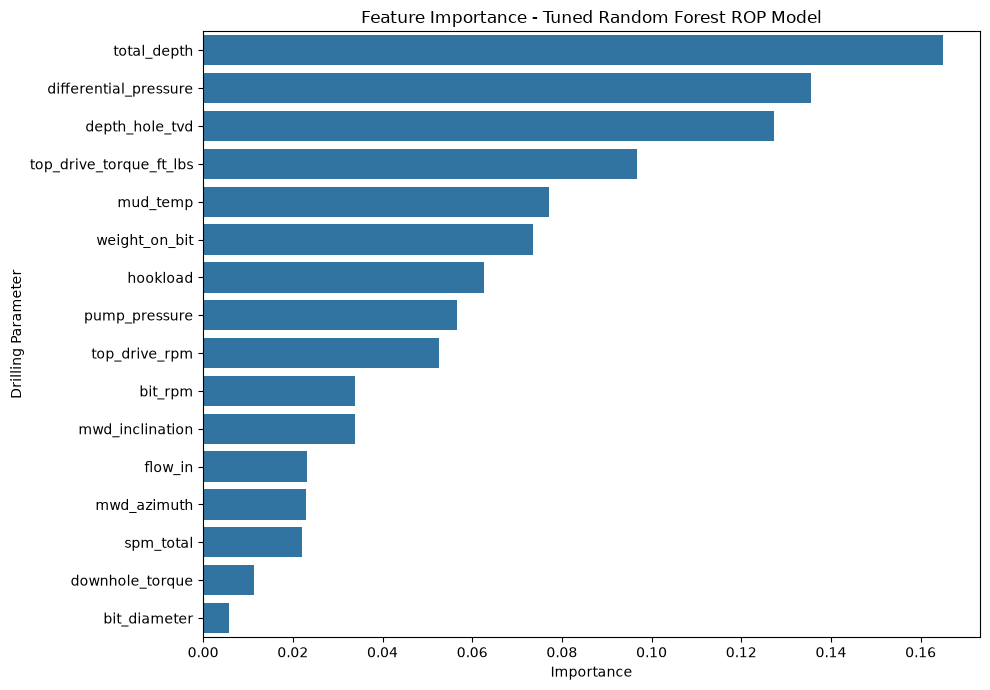

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title(
    'Feature Importance - Tuned Random Forest ROP Model'
)

plt.xlabel('Importance')
plt.ylabel('Drilling Parameter')

plt.tight_layout()
plt.show()

# 15. Final model diagnostics

## 15.1 Actual vs Predicted ROP

This plot compares the true ROP values with predictions from the **tuned Random Forest**.

The diagonal reference line represents perfect predictions:
- Points close to the line indicate accurate predictions.
- Points far from the line indicate larger prediction errors.

A strong model should show most observations concentrated around the diagonal.


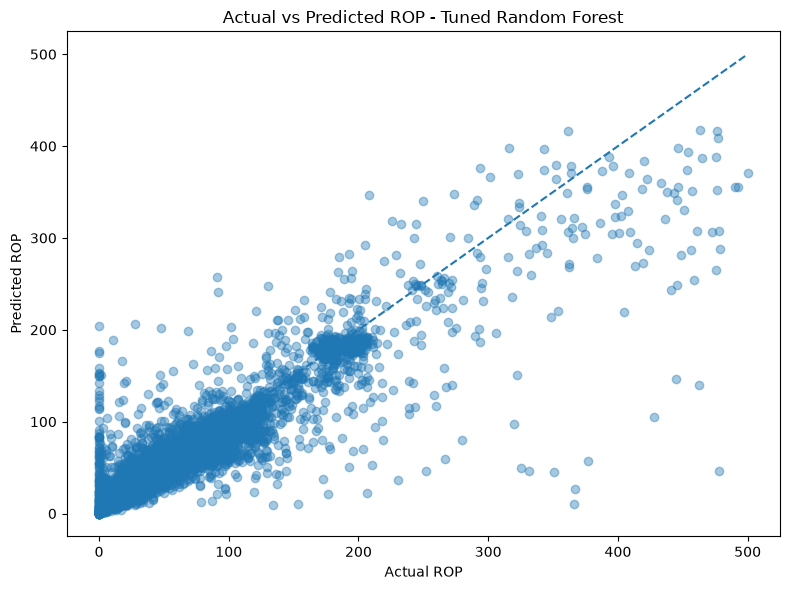

In [88]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_tuned,
    alpha=0.4
)

min_val = min(y_test.min(), y_pred_tuned.min())
max_val = max(y_test.max(), y_pred_tuned.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    '--'
)

plt.xlabel('Actual ROP')
plt.ylabel('Predicted ROP')

plt.title(
    'Actual vs Predicted ROP - Tuned Random Forest'
)

plt.tight_layout()
plt.show()

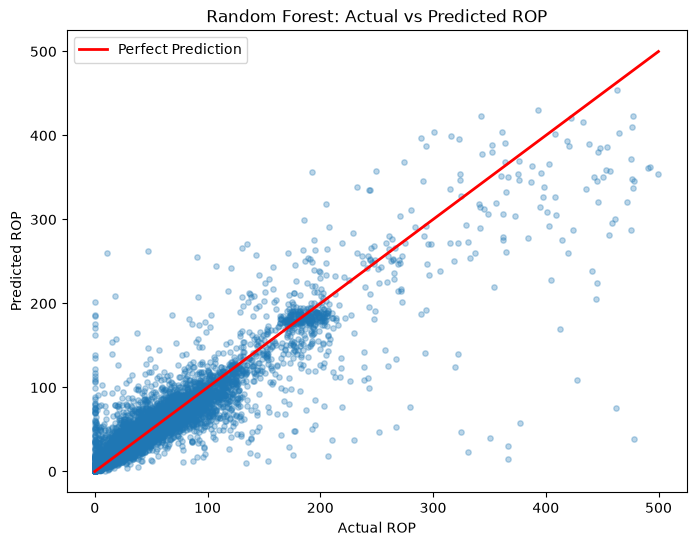

In [89]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, s=15, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual ROP")
plt.ylabel("Predicted ROP")
plt.title("Random Forest: Actual vs Predicted ROP")

plt.legend()

plt.show()

## 15.2 Residual analysis

A residual is calculated as:

**Residual = Actual ROP − Predicted ROP**

Ideally, residuals should be distributed around zero without a strong systematic pattern.

- Residual near zero → accurate prediction.
- Positive residual → the model underpredicted ROP.
- Negative residual → the model overpredicted ROP.

Patterns in the residual plot can reveal ranges where the model struggles.


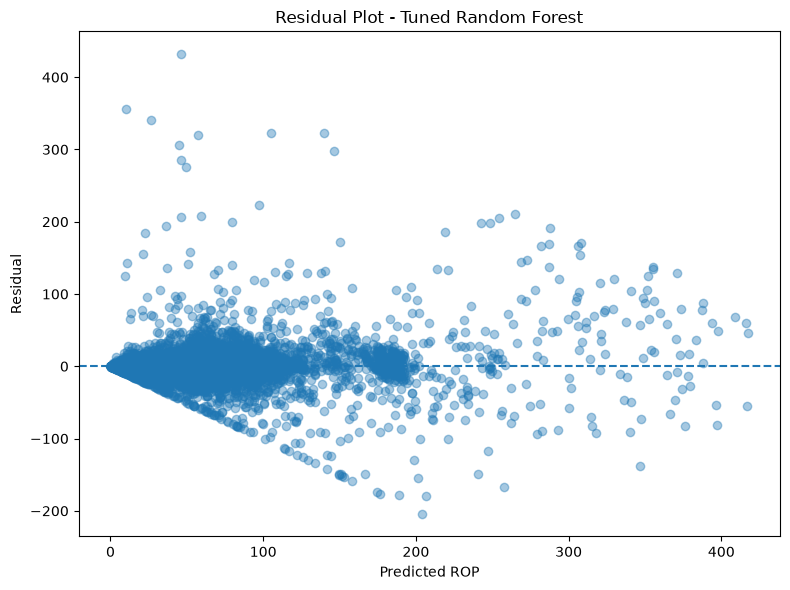

In [90]:
residuals = y_test - y_pred_tuned

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_tuned,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted ROP')
plt.ylabel('Residual')

plt.title(
    'Residual Plot - Tuned Random Forest'
)

plt.tight_layout()
plt.show()

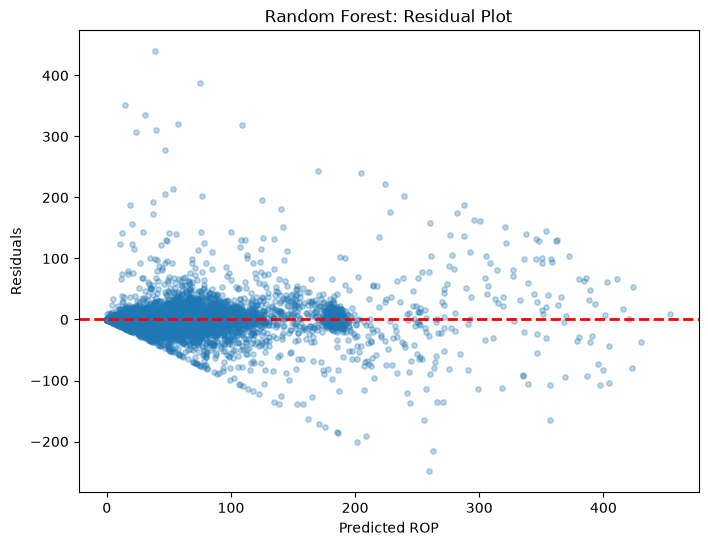

In [91]:
#Residual plot 
residuals = y_test - y_pred_rf
plt.figure(figsize=(8,6))

plt.scatter(y_pred_rf, residuals, alpha=0.3, s=15)

plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.xlabel("Predicted ROP")
plt.ylabel("Residuals")
plt.title("Random Forest: Residual Plot")

plt.show()

## 15.3 Error distribution

The error-distribution plot shows how frequently different prediction errors occur.

A useful model should have a large concentration of residuals around zero. A wide or strongly skewed distribution indicates that larger errors occur for some drilling conditions.

For the final report, diagnostic plots should preferably use predictions from the **tuned Random Forest**, since that is the selected final model.


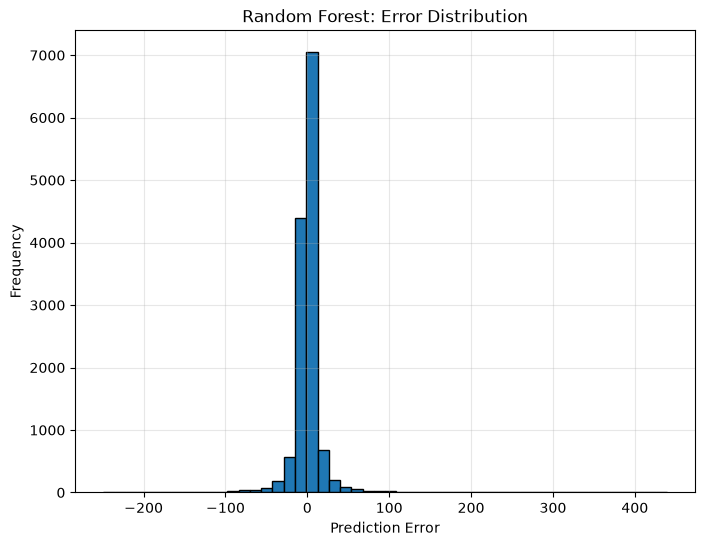

In [92]:
#Error distribution
plt.figure(figsize=(8,6))
residuals = y_test - y_pred_rf

plt.hist(residuals, bins=50, edgecolor='black')

plt.title("Random Forest: Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)
plt.show()

# 16. Model Serialization and Deployment Preparation

The final tuned Random Forest model is serialized using `joblib` so that it can be reused later without retraining.

The saved `.pkl` package contains:

- The trained Random Forest model
- The fitted imputer
- The exact feature column order
- Target variable information
- Scikit-learn version
- Random state

This ensures that the same preprocessing and model configuration can be reproduced during deployment.

In [93]:
import os
import joblib
import sklearn
import numpy as np

## 16.1 Save the Tuned Random Forest Model

The best estimator obtained from `RandomizedSearchCV` is saved as a `.pkl` file.

Instead of saving only the Random Forest model, the preprocessing object and feature information are also stored. This helps maintain consistency between model training and future inference.

In [94]:
# ============================================================
# SAVE TUNED RANDOM FOREST MODEL
# ============================================================

# Retrieve the best model from hyperparameter tuning
best_rf_model = random_search.best_estimator_

# Store model and required preprocessing information
model_package = {
    "model": best_rf_model,
    "imputer": imputer,
    "feature_columns": list(X_train_imputed.columns),
    "target_name": y_train.name if hasattr(y_train, "name") else "ROP",
    "sklearn_version": sklearn.__version__,
    "random_state": 42
}

# Output file
pkl_path = "ROP_RandomForest_Tuned_Model.pkl"

# Save package
joblib.dump(model_package, pkl_path)

print("=" * 60)
print("MODEL SERIALIZATION COMPLETE")
print("=" * 60)
print(f"File: {pkl_path}")
print(f"File size: {os.path.getsize(pkl_path) / (1024**2):.2f} MB")
print(f"Number of features: {len(model_package['feature_columns'])}")
print(f"Scikit-learn version: {model_package['sklearn_version']}")
print("=" * 60)

MODEL SERIALIZATION COMPLETE
File: ROP_RandomForest_Tuned_Model.pkl
File size: 589.56 MB
Number of features: 16
Scikit-learn version: 1.9.0


## 16.2 Verify the Saved Model

The saved `.pkl` file is reloaded and checked to ensure that:

1. The file exists and can be loaded.
2. All required components are present.
3. The saved feature columns match the training feature columns.
4. The loaded object is a `RandomForestRegressor`.
5. The saved imputer is available.
6. Predictions from the reloaded model match the original tuned model.
7. The saved preprocessing pipeline can handle missing values correctly.

A prediction-equivalence check is used to confirm that serialization did not alter the model.

In [95]:
# ============================================================
# VERIFY SAVED PKL MODEL
# ============================================================

print("=" * 60)
print("VERIFYING SAVED PKL MODEL")
print("=" * 60)

# ------------------------------------------------------------
# 1. Verify file exists
# ------------------------------------------------------------

if not os.path.exists(pkl_path):
    raise FileNotFoundError(
        f"PKL file was not created: {pkl_path}"
    )

print("✅ PKL file exists")


# ------------------------------------------------------------
# 2. Load saved package
# ------------------------------------------------------------

loaded_package = joblib.load(pkl_path)

print("✅ PKL file loaded successfully")


# ------------------------------------------------------------
# 3. Verify required components
# ------------------------------------------------------------

required_keys = [
    "model",
    "imputer",
    "feature_columns",
    "target_name",
    "sklearn_version",
    "random_state"
]

missing_keys = [
    key for key in required_keys
    if key not in loaded_package
]

if missing_keys:
    raise ValueError(
        f"Missing components in PKL: {missing_keys}"
    )

print("✅ All required components are present")


# ------------------------------------------------------------
# 4. Extract saved components
# ------------------------------------------------------------

loaded_model = loaded_package["model"]
loaded_imputer = loaded_package["imputer"]
saved_features = loaded_package["feature_columns"]


# ------------------------------------------------------------
# 5. Verify feature columns
# ------------------------------------------------------------

current_features = list(X_train_imputed.columns)

if saved_features != current_features:
    raise ValueError(
        "Feature mismatch detected!\n\n"
        f"Saved features:\n{saved_features}\n\n"
        f"Current features:\n{current_features}"
    )

print("✅ Feature columns and order match")


# ------------------------------------------------------------
# 6. Verify model type
# ------------------------------------------------------------

if not isinstance(loaded_model, RandomForestRegressor):
    raise TypeError(
        "Loaded model is not a RandomForestRegressor"
    )

print("✅ Model type verified: RandomForestRegressor")


# ------------------------------------------------------------
# 7. Verify imputer
# ------------------------------------------------------------

if not isinstance(loaded_imputer, SimpleImputer):
    raise TypeError(
        "Loaded preprocessing object is not SimpleImputer"
    )

print("✅ Imputer verified")


# ------------------------------------------------------------
# 8. Compare predictions
# ------------------------------------------------------------

# Original tuned model predictions
original_predictions = best_rf_model.predict(
    X_test_imputed
)

# Reloaded PKL model predictions
loaded_predictions = loaded_model.predict(
    X_test_imputed
)

# Compare predictions
predictions_match = np.allclose(
    original_predictions,
    loaded_predictions,
    rtol=1e-10,
    atol=1e-10
)

if not predictions_match:

    max_difference = np.max(
        np.abs(
            original_predictions - loaded_predictions
        )
    )

    raise ValueError(
        f"Prediction mismatch detected!\n"
        f"Maximum difference: {max_difference}"
    )

print("✅ Reloaded model produces identical predictions")


# ------------------------------------------------------------
# 9. Verify saved imputer
# ------------------------------------------------------------

test_imputed_loaded = pd.DataFrame(
    loaded_imputer.transform(X_test),
    columns=saved_features,
    index=X_test.index
)

missing_after_imputation = (
    test_imputed_loaded.isnull().sum().sum()
)

if missing_after_imputation != 0:
    raise ValueError(
        "Loaded imputer produced missing values"
    )

print("✅ Reloaded imputer successfully handles missing values")


# ------------------------------------------------------------
# FINAL VERIFICATION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("✅ MODEL VERIFICATION PASSED")
print("=" * 60)

print(f"PKL file: {pkl_path}")
print(f"Model: {type(loaded_model).__name__}")
print(f"Features: {len(saved_features)}")
print(f"Test samples verified: {len(X_test_imputed)}")
print(f"Scikit-learn version: {loaded_package['sklearn_version']}")

print("=" * 60)

VERIFYING SAVED PKL MODEL
✅ PKL file exists
✅ PKL file loaded successfully
✅ All required components are present
✅ Feature columns and order match
✅ Model type verified: RandomForestRegressor
✅ Imputer verified
✅ Reloaded model produces identical predictions
✅ Reloaded imputer successfully handles missing values

✅ MODEL VERIFICATION PASSED
PKL file: ROP_RandomForest_Tuned_Model.pkl
Model: RandomForestRegressor
Features: 16
Test samples verified: 13540
Scikit-learn version: 1.9.0


## 16.3 Final Inference Test

The serialized model is tested independently using a small sample from the test dataset.

This confirms that the `.pkl` file can perform inference using the saved preprocessing and model objects, which is important before integrating the model into the deployment API.

In [96]:
# ============================================================
# FINAL PKL INFERENCE TEST
# ============================================================

# Select a small sample from the test dataset
sample_input = X_test.iloc[:5].copy()

# Apply the saved imputer
sample_input_imputed = pd.DataFrame(
    loaded_imputer.transform(sample_input),
    columns=saved_features,
    index=sample_input.index
)

# Generate predictions using ONLY the reloaded model
sample_predictions = loaded_model.predict(
    sample_input_imputed
)

print("=" * 60)
print("FINAL PKL INFERENCE TEST")
print("=" * 60)

print(f"Input shape: {sample_input.shape}")
print(f"Prediction shape: {sample_predictions.shape}")

print("\nPredictions:")
print(sample_predictions)

print("\n✅ PKL MODEL IS READY FOR DEPLOYMENT")
print("=" * 60)

FINAL PKL INFERENCE TEST
Input shape: (5, 16)
Prediction shape: (5,)

Predictions:
[ 12.25021518  59.72981644 145.85234118  23.77805539  96.04804538]

✅ PKL MODEL IS READY FOR DEPLOYMENT


## Model Metadata Generation and Verification

A separate metadata file is generated alongside the serialized model to document the model artifact and its deployment requirements.

The metadata records the model type, target variable, feature names, number of features, preprocessing method, training configuration, and scikit-learn version.

The metadata file is then reloaded and verified to ensure that it was created successfully and contains the expected information.

In [97]:
# ============================================================
# CREATE MODEL METADATA FILE
# ============================================================

import json
from datetime import datetime

metadata = {
    "model_file": pkl_path,
    "model_type": type(loaded_model).__name__,
    "target_variable": loaded_package["target_name"],
    "feature_columns": saved_features,
    "number_of_features": len(saved_features),
    "preprocessing": {
        "imputer": type(loaded_imputer).__name__,
        "strategy": loaded_imputer.strategy
    },
    "random_state": loaded_package["random_state"],
    "sklearn_version": loaded_package["sklearn_version"],
    "training_samples": len(X_train_imputed),
    "test_samples": len(X_test_imputed),
    "metadata_created": datetime.now().isoformat()
}

# Metadata output file
metadata_path = "ROP_RandomForest_Tuned_Model_metadata.json"

# Save metadata
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

print("=" * 60)
print("MODEL METADATA CREATED")
print("=" * 60)
print(f"Metadata file: {metadata_path}")
print(f"File size: {os.path.getsize(metadata_path) / 1024:.2f} KB")
print("=" * 60)

MODEL METADATA CREATED
Metadata file: ROP_RandomForest_Tuned_Model_metadata.json
File size: 0.84 KB


## Metadata File Verification

The generated metadata file is reloaded and checked to confirm that:

- The file exists.
- The JSON file can be successfully loaded.
- All required metadata fields are present.
- The recorded model type matches the serialized model.
- The recorded feature count matches the saved feature list.
- The referenced `.pkl` model file exists.

In [98]:
# ============================================================
# VERIFY MODEL METADATA
# ============================================================

print("=" * 60)
print("VERIFYING MODEL METADATA")
print("=" * 60)

# ------------------------------------------------------------
# 1. Verify metadata file exists
# ------------------------------------------------------------

if not os.path.exists(metadata_path):
    raise FileNotFoundError(
        f"Metadata file was not created: {metadata_path}"
    )

print("✅ Metadata file exists")


# ------------------------------------------------------------
# 2. Load metadata
# ------------------------------------------------------------

with open(metadata_path, "r", encoding="utf-8") as f:
    loaded_metadata = json.load(f)

print("✅ Metadata JSON loaded successfully")


# ------------------------------------------------------------
# 3. Verify required fields
# ------------------------------------------------------------

required_metadata = [
    "model_file",
    "model_type",
    "target_variable",
    "feature_columns",
    "number_of_features",
    "preprocessing",
    "random_state",
    "sklearn_version"
]

missing_metadata = [
    key for key in required_metadata
    if key not in loaded_metadata
]

if missing_metadata:
    raise ValueError(
        f"Missing metadata fields: {missing_metadata}"
    )

print("✅ All required metadata fields are present")


# ------------------------------------------------------------
# 4. Verify model file reference
# ------------------------------------------------------------

if not os.path.exists(loaded_metadata["model_file"]):
    raise FileNotFoundError(
        "Referenced PKL model file does not exist"
    )

print("✅ Referenced PKL model file exists")


# ------------------------------------------------------------
# 5. Verify model type
# ------------------------------------------------------------

if loaded_metadata["model_type"] != type(loaded_model).__name__:
    raise ValueError(
        "Model type in metadata does not match the loaded model"
    )

print("✅ Model type matches")


# ------------------------------------------------------------
# 6. Verify feature count
# ------------------------------------------------------------

if (
    loaded_metadata["number_of_features"]
    != len(loaded_metadata["feature_columns"])
):
    raise ValueError(
        "Feature count does not match feature list"
    )

print("✅ Feature count matches feature list")


# ------------------------------------------------------------
# 7. Verify feature columns
# ------------------------------------------------------------

if loaded_metadata["feature_columns"] != saved_features:
    raise ValueError(
        "Metadata feature columns do not match the PKL model"
    )

print("✅ Feature columns match PKL model")


# ------------------------------------------------------------
# FINAL RESULT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("✅ METADATA VERIFICATION PASSED")
print("=" * 60)

print(f"Model file    : {loaded_metadata['model_file']}")
print(f"Metadata file : {metadata_path}")
print(f"Model type    : {loaded_metadata['model_type']}")
print(f"Features      : {loaded_metadata['number_of_features']}")
print(f"Target        : {loaded_metadata['target_variable']}")

print("=" * 60)

VERIFYING MODEL METADATA
✅ Metadata file exists
✅ Metadata JSON loaded successfully
✅ All required metadata fields are present
✅ Referenced PKL model file exists
✅ Model type matches
✅ Feature count matches feature list
✅ Feature columns match PKL model

✅ METADATA VERIFICATION PASSED
Model file    : ROP_RandomForest_Tuned_Model.pkl
Metadata file : ROP_RandomForest_Tuned_Model_metadata.json
Model type    : RandomForestRegressor
Features      : 16
Target        : rop_depth_hour


## 17.Lightweight Deployment Model

The fully tuned Random Forest is retained as the primary research model. However, its serialized size is relatively large for deployment.

A separate lightweight Random Forest is therefore trained using a constrained configuration designed to reduce:

- Model size
- Memory consumption
- Model loading time
- Prediction latency

The lightweight model is intended for deployment through the IntelliWell API, while the fully tuned model remains available as the reference research model.

The deployment model is evaluated on the same unseen test set to ensure that the reduction in model complexity does not cause an unacceptable loss in predictive performance.

In [99]:
# ============================================================
# LIGHTWEIGHT DEPLOYMENT RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
import os
import joblib

deployment_rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features=0.7,
    random_state=42,
    n_jobs=-1
)

print("=" * 60)
print("TRAINING LIGHTWEIGHT DEPLOYMENT MODEL")
print("=" * 60)

start_time = time.time()

deployment_rf.fit(
    X_train_imputed,
    y_train
)

training_time = time.time() - start_time

print(f"Training time: {training_time / 60:.2f} minutes")
print("✅ Deployment model trained")

TRAINING LIGHTWEIGHT DEPLOYMENT MODEL
Training time: 0.07 minutes
✅ Deployment model trained


In [100]:
# ============================================================
# DEPLOYMENT MODEL EVALUATION
# ============================================================

deployment_predictions = deployment_rf.predict(
    X_test_imputed
)

deployment_rmse = np.sqrt(
    mean_squared_error(y_test, deployment_predictions)
)

deployment_mae = mean_absolute_error(
    y_test,
    deployment_predictions
)

deployment_r2 = r2_score(
    y_test,
    deployment_predictions
)

print("=" * 60)
print("LIGHTWEIGHT DEPLOYMENT MODEL PERFORMANCE")
print("=" * 60)

print(f"RMSE : {deployment_rmse:.4f}")
print(f"MAE  : {deployment_mae:.4f}")
print(f"R²   : {deployment_r2:.4f}")

print("\nReference tuned model:")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, original_predictions)):.4f}")
print(f"MAE  : {mean_absolute_error(y_test, original_predictions):.4f}")
print(f"R²   : {r2_score(y_test, original_predictions):.4f}")

LIGHTWEIGHT DEPLOYMENT MODEL PERFORMANCE
RMSE : 20.6097
MAE  : 8.7886
R²   : 0.8376

Reference tuned model:
RMSE : 20.4660
MAE  : 8.6772
R²   : 0.8399


In [101]:
# ============================================================
# SAVE LIGHTWEIGHT DEPLOYMENT MODEL
# ============================================================

deployment_package = {
    "model": deployment_rf,
    "imputer": imputer,
    "feature_columns": list(X_train_imputed.columns),
    "target_name": y_train.name if hasattr(y_train, "name") else "ROP",
    "model_type": "Lightweight Deployment Random Forest",
    "sklearn_version": sklearn.__version__,
    "random_state": 42
}

deployment_pkl_path = "ROP_RandomForest_Deployment.pkl"

start_time = time.time()

joblib.dump(
    deployment_package,
    deployment_pkl_path
)

serialization_time = time.time() - start_time

deployment_size_mb = (
    os.path.getsize(deployment_pkl_path)
    / (1024 ** 2)
)

print("=" * 60)
print("DEPLOYMENT MODEL SERIALIZATION COMPLETE")
print("=" * 60)

print(f"File: {deployment_pkl_path}")
print(f"File size: {deployment_size_mb:.2f} MB")
print(f"Serialization time: {serialization_time:.2f} seconds")
print("=" * 60)

DEPLOYMENT MODEL SERIALIZATION COMPLETE
File: ROP_RandomForest_Deployment.pkl
File size: 142.97 MB
Serialization time: 0.03 seconds


## Deployment Model Verification

The deployment `.pkl` file is reloaded and verified independently.

The verification checks that:

- The deployment artifact exists.
- The serialized model can be loaded successfully.
- The expected model components are present.
- Feature ordering is preserved.
- The reloaded model produces the same predictions as the model before serialization.

This confirms that the lightweight model is safe to use as the deployment artifact.

In [102]:
# ============================================================
# VERIFY LIGHTWEIGHT DEPLOYMENT MODEL
# ============================================================

print("=" * 60)
print("VERIFYING DEPLOYMENT MODEL")
print("=" * 60)

# 1. File existence
if not os.path.exists(deployment_pkl_path):
    raise FileNotFoundError(
        f"Deployment PKL not found: {deployment_pkl_path}"
    )

print("✅ Deployment PKL exists")


# 2. Load package
loaded_deployment_package = joblib.load(
    deployment_pkl_path
)

print("✅ Deployment PKL loaded successfully")


# 3. Required components
required_keys = [
    "model",
    "imputer",
    "feature_columns",
    "target_name",
    "model_type",
    "sklearn_version",
    "random_state"
]

missing_keys = [
    key for key in required_keys
    if key not in loaded_deployment_package
]

if missing_keys:
    raise ValueError(
        f"Missing deployment components: {missing_keys}"
    )

print("✅ Required components verified")


# 4. Extract components
loaded_deployment_model = (
    loaded_deployment_package["model"]
)

loaded_deployment_imputer = (
    loaded_deployment_package["imputer"]
)

loaded_deployment_features = (
    loaded_deployment_package["feature_columns"]
)


# 5. Feature verification
if loaded_deployment_features != list(
    X_train_imputed.columns
):
    raise ValueError(
        "Deployment feature order does not match training features"
    )

print("✅ Feature order verified")


# 6. Prediction equivalence
reloaded_predictions = (
    loaded_deployment_model.predict(X_test_imputed)
)

if not np.allclose(
    deployment_predictions,
    reloaded_predictions,
    rtol=1e-10,
    atol=1e-10
):
    raise ValueError(
        "Reloaded deployment model predictions do not match"
    )

print("✅ Reloaded model produces identical predictions")


# Final result
print("\n" + "=" * 60)
print("✅ DEPLOYMENT MODEL VERIFICATION PASSED")
print("=" * 60)

print(f"Model file: {deployment_pkl_path}")
print(f"Model size: {deployment_size_mb:.2f} MB")
print(f"Trees: {loaded_deployment_model.n_estimators}")
print(f"Max depth: {loaded_deployment_model.max_depth}")
print("=" * 60)

VERIFYING DEPLOYMENT MODEL
✅ Deployment PKL exists
✅ Deployment PKL loaded successfully
✅ Required components verified
✅ Feature order verified
✅ Reloaded model produces identical predictions

✅ DEPLOYMENT MODEL VERIFICATION PASSED
Model file: ROP_RandomForest_Deployment.pkl
Model size: 142.97 MB
Trees: 150
Max depth: 20


In [103]:
# ============================================================
# DEPLOYMENT MODEL METADATA
# ============================================================

deployment_metadata = {
    "model_file": deployment_pkl_path,
    "model_type": type(loaded_deployment_model).__name__,
    "purpose": "Production deployment",
    "target_variable": loaded_deployment_package["target_name"],
    "feature_columns": loaded_deployment_features,
    "number_of_features": len(loaded_deployment_features),
    "n_estimators": loaded_deployment_model.n_estimators,
    "max_depth": loaded_deployment_model.max_depth,
    "min_samples_split": loaded_deployment_model.min_samples_split,
    "min_samples_leaf": loaded_deployment_model.min_samples_leaf,
    "max_features": loaded_deployment_model.max_features,
    "test_rmse": float(deployment_rmse),
    "test_mae": float(deployment_mae),
    "test_r2": float(deployment_r2),
    "sklearn_version": loaded_deployment_package["sklearn_version"],
    "random_state": loaded_deployment_package["random_state"]
}

deployment_metadata_path = (
    "ROP_RandomForest_Deployment_metadata.json"
)

with open(
    deployment_metadata_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        deployment_metadata,
        f,
        indent=4
    )

print("=" * 60)
print("DEPLOYMENT METADATA CREATED")
print("=" * 60)
print(f"File: {deployment_metadata_path}")
print(
    f"Size: "
    f"{os.path.getsize(deployment_metadata_path) / 1024:.2f} KB"
)
print("=" * 60)

DEPLOYMENT METADATA CREATED
File: ROP_RandomForest_Deployment_metadata.json
Size: 0.90 KB


# 17. Final conclusion

This notebook developed an ML pipeline for predicting **Rate of Penetration during active drilling**.

The workflow first isolated active positive-ROP observations and reduced the influence of the extreme ROP tail. Relevant drilling, hydraulic, mechanical, directional, depth, and mud-related measurements were then used as predictors.

Four ensemble regression algorithms were compared:
- Random Forest
- XGBoost
- LightGBM
- CatBoost

Random Forest achieved the strongest baseline performance and was therefore selected for hyperparameter tuning. The tuned model improved the test-set performance further.

### Final tuned Random Forest performance
- **MAE:** approximately **8.67**
- **RMSE:** approximately **20.46**
- **R²:** approximately **0.84**

An R² of about 0.84 means that, on this random holdout, the model explains roughly **84% of the observed variation in ROP**.

### Important limitation
Earlier chronological testing showed that performance can deteriorate when the model is asked to predict a later drilling interval with substantially different depth and operating conditions. Therefore, the strong random-holdout result should be interpreted mainly as evidence of good **interpolation across representative conditions**, not guaranteed extrapolation to completely new drilling regimes.

### Final takeaway
The tuned Random Forest provides a strong ROP prediction model for the conditions represented in the training data. Feature importance and residual analysis help explain the model and identify where its predictions are most reliable.
